In [1]:
%pip install xlrd

  Using cached xlrd-2.0.2-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached xlrd-2.0.2-py2.py3-none-any.whl (96 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: D:\Programming\DAv2\.venv\Scripts\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import xlrd as xlrd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel('US Superstore data.xls', sheet_name='Orders')

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [6]:
# Check for missing values during preprocessing
missing_values = df.isnull().sum()
print("Missing values by column:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")


Missing values by column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Total missing values: 0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


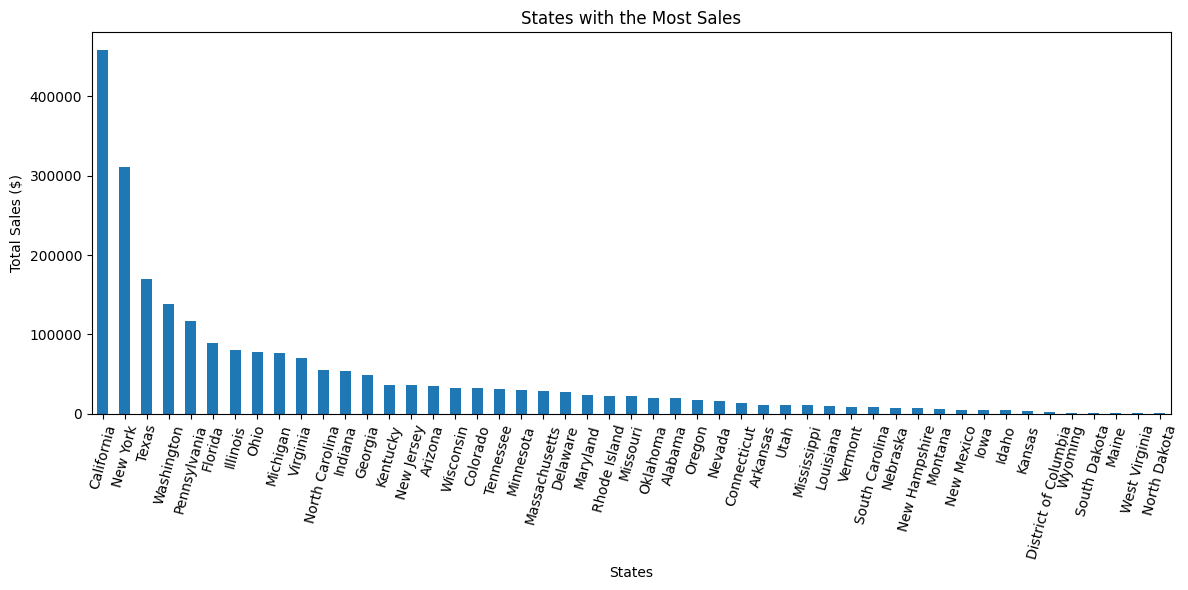

In [9]:
#Which states have the most sales?
most_sales_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
ax = most_sales_states.plot(kind='bar', figsize=(12, 6))

ax.set_title('States with the Most Sales')
ax.set_xlabel('States')
ax.set_ylabel('Total Sales ($)')
ax.tick_params(axis='x', labelrotation=75)

plt.tight_layout()
plt.show()


In [10]:
#What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)
new_york_sales = df[df['State'] == 'New York']['Sales'].sum()
california_sales = df[df['State'] == 'California']['Sales'].sum()
new_york_profit = df[df['State'] == 'New York']['Profit'].sum()
california_profit = df[df['State'] == 'California']['Profit'].sum()

print(f"New York Sales: {new_york_sales}")
print(f"California Sales: {california_sales}")
print(f"New York Profit: {new_york_profit}")
print(f"California Profit: {california_profit}")
# Compare sales
if new_york_sales > california_sales:
    print(f"New York has ${new_york_sales - california_sales:,.2f} more in sales.")
elif california_sales > new_york_sales:
    print(f"California has ${california_sales - new_york_sales:,.2f} more in sales.")
else:
    print("New York and California have equal sales.")

# Compare profit
if new_york_profit > california_profit:
    print(f"New York has ${new_york_profit - california_profit:,.2f} more in profit.")
elif california_profit > new_york_profit:
    print(f"California has ${california_profit - new_york_profit:,.2f} more in profit.")
else:
    print("New York and California have equal profit.")

New York Sales: 310876.27099999995
California Sales: 457687.6315
New York Profit: 74038.54859999998
California Profit: 76381.38709999998
California has $146,811.36 more in sales.
California has $2,342.84 more in profit.


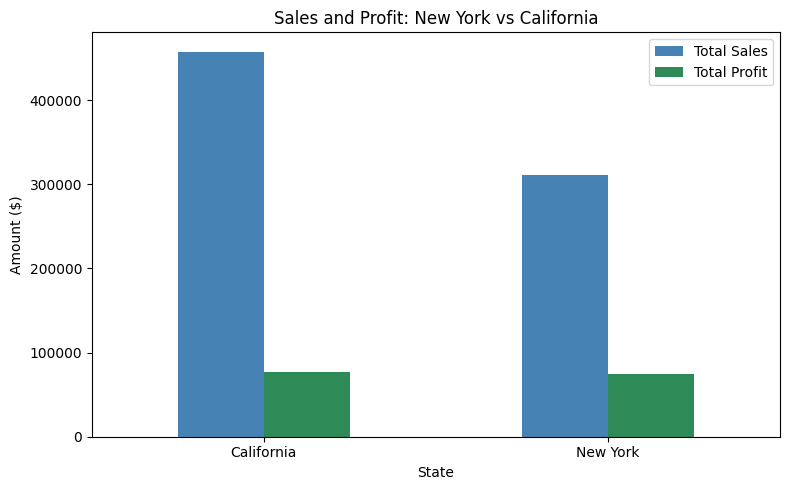

In [11]:
# Visual comparison of New York and California
ny_ca_comparison = (
    df[df['State'].isin(['New York', 'California'])]
    .groupby('State')[['Sales', 'Profit']]
    .sum()
)

ax = ny_ca_comparison.plot(
    kind='bar',
    figsize=(8, 5),
    color=['steelblue', 'seagreen']
)
ax.set_title('Sales and Profit: New York vs California')
ax.set_xlabel('State')
ax.set_ylabel('Amount ($)')
ax.tick_params(axis='x', labelrotation=0)
ax.legend(['Total Sales', 'Total Profit'])

plt.tight_layout()
plt.show()


In [12]:
#Who is an outstanding customer in New York?
outstanding_customer_ny = df[df['State'] == 'New York'].groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).index[0]
print(f"Outstanding customer in New York: {outstanding_customer_ny}")

Outstanding customer in New York: Tom Ashbrook


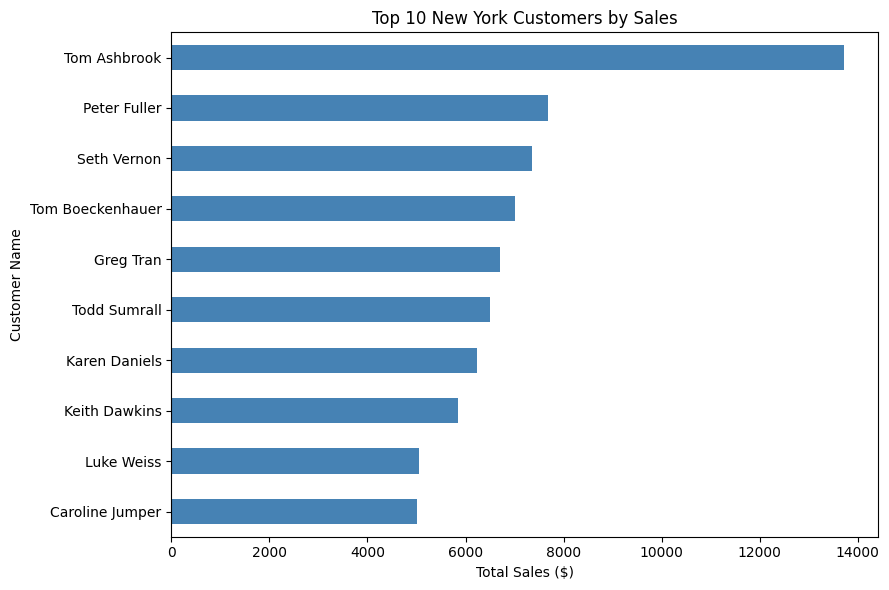

In [13]:
# Visualize the leading customers in New York
top_10_ny_customers = (
    df[df['State'] == 'New York']
    .groupby('Customer Name')['Sales']
    .sum()
    .nlargest(10)
    .sort_values()
)

ax = top_10_ny_customers.plot(
    kind='barh',
    figsize=(9, 6),
    color='steelblue'
)
ax.set_title('Top 10 New York Customers by Sales')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Customer Name')

plt.tight_layout()
plt.show()


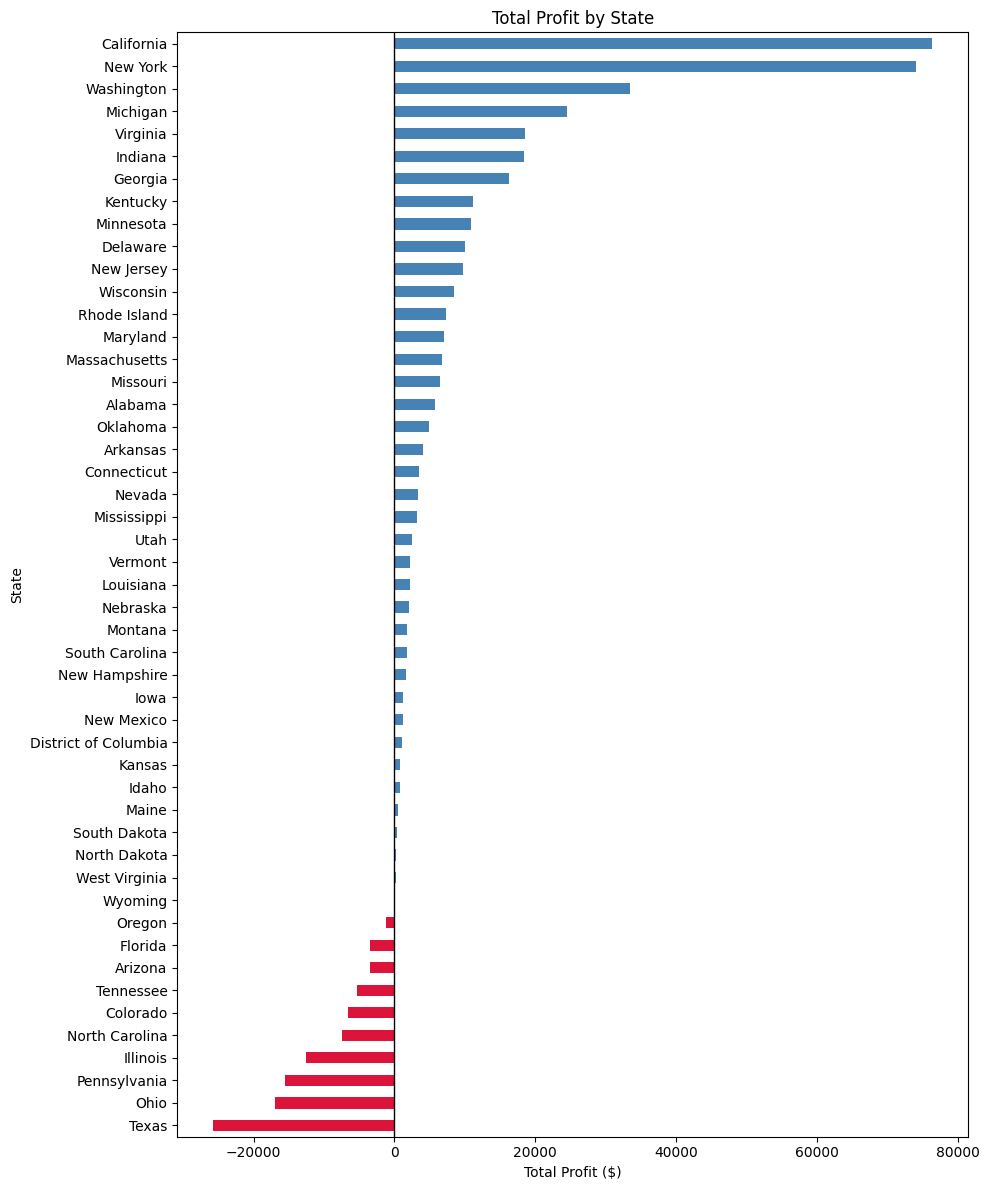

Most profitable state: California ($76,381.39)
Least profitable state: Texas ($-25,729.36)
Loss-making states: Texas, Ohio, Pennsylvania, Illinois, North Carolina, Colorado, Tennessee, Arizona, Florida, Oregon


In [14]:
#Are there any differences among states in profitability?
state_performance = df.groupby('State').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)
state_performance['Profit_Margin_%'] = (
    state_performance['Total_Profit'] / state_performance['Total_Sales'] * 100
)

profitability_by_state = state_performance['Total_Profit'].sort_values()
colors = [
    'crimson' if profit < 0 else 'steelblue'
    for profit in profitability_by_state
]

ax = profitability_by_state.plot(
    kind='barh',
    figsize=(10, 12),
    color=colors
)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Total Profit by State')
ax.set_xlabel('Total Profit ($)')
ax.set_ylabel('State')

plt.tight_layout()
plt.show()

most_profitable_state = profitability_by_state.idxmax()
least_profitable_state = profitability_by_state.idxmin()

print(
    f"Most profitable state: {most_profitable_state} "
    f"(${profitability_by_state.loc[most_profitable_state]:,.2f})"
)
print(
    f"Least profitable state: {least_profitable_state} "
    f"(${profitability_by_state.loc[least_profitable_state]:,.2f})"
)
print(
    f"Loss-making states: "
    f"{', '.join(profitability_by_state[profitability_by_state < 0].index)}"
)


Total customers: 793
Customers in the top 20%: 159
Total profit: $286,397.02
Profit from top 20% of customers: $233,885.47
Percentage of profit from top 20% of customers: 81.66%
Conclusion: The Pareto principle applies to customer profit.


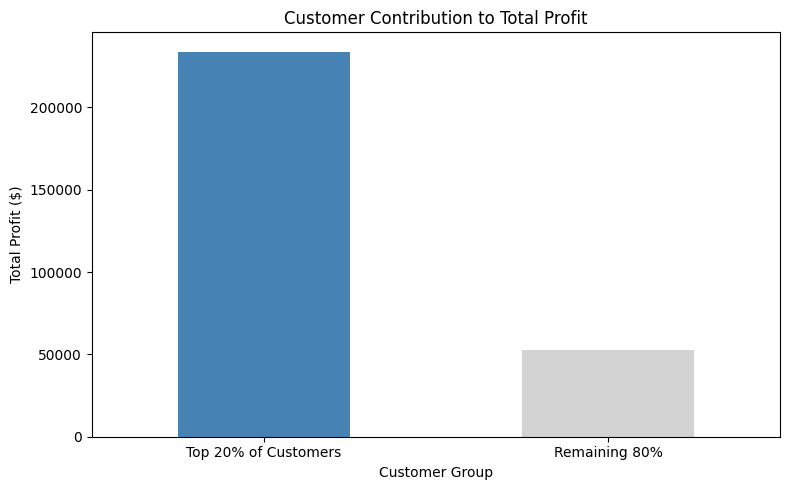

In [15]:
#The Pareto Principle, also known as the 80/20 rule, asks whether 20% of customers generate 80% of profit.
customer_profit = (
    df.groupby('Customer Name')['Profit']
    .sum()
    .sort_values(ascending=False)
)

total_profit = customer_profit.sum()
top_20_percent_count = int(np.ceil(0.20 * len(customer_profit)))
top_20_percent_customers = customer_profit.head(top_20_percent_count)
top_20_percent_profit = top_20_percent_customers.sum()
profit_share = top_20_percent_profit / total_profit * 100

print(f"Total customers: {len(customer_profit)}")
print(f"Customers in the top 20%: {top_20_percent_count}")
print(f"Total profit: ${total_profit:,.2f}")
print(f"Profit from top 20% of customers: ${top_20_percent_profit:,.2f}")
print(f"Percentage of profit from top 20% of customers: {profit_share:.2f}%")

if profit_share >= 80:
    print("Conclusion: The Pareto principle applies to customer profit.")
else:
    print("Conclusion: The Pareto principle does not strictly apply to customer profit.")

profit_split = pd.Series({
    'Top 20% of Customers': top_20_percent_profit,
    'Remaining 80%': total_profit - top_20_percent_profit
})

ax = profit_split.plot(
    kind='bar',
    figsize=(8, 5),
    color=['steelblue', 'lightgray']
)
ax.set_title('Customer Contribution to Total Profit')
ax.set_xlabel('Customer Group')
ax.set_ylabel('Total Profit ($)')
ax.tick_params(axis='x', labelrotation=0)

plt.tight_layout()
plt.show()


In [16]:
#What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ?
top_20_cities_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)
top_20_cities_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)
print("Top 20 Cities by Sales:")
print(top_20_cities_sales)

Top 20 Cities by Sales:
City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Detroit           42446.9440
Columbus          38706.2430
Newark            28576.1190
Columbia          25283.3240
Lafayette         25036.2000
Jackson           24963.8580
San Antonio       21843.5280
Burlington        21668.0820
Arlington         20214.5320
Dallas            20131.9322
Name: Sales, dtype: float64


In [17]:
print("\nTop 20 Cities by Profit:")
print(top_20_cities_profit)


Top 20 Cities by Profit:
City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Lafayette        10018.3876
Jackson           7581.6828
Atlanta           6993.6629
Minneapolis       6824.5846
San Diego         6377.1960
Springfield       6200.6974
Columbus          5897.1013
Newark            5793.7588
Columbia          5606.1167
Richmond          5567.2486
Providence        5505.6569
Henderson         4911.8609
Arlington         4169.6969
Lakewood          3234.0278
Milwaukee         2793.0851
Name: Profit, dtype: float64


In [18]:
#Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)
city_performance = df.groupby('City').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)

city_performance['Profit_Margin_%'] = (
    city_performance['Total_Profit']
    / city_performance['Total_Sales']
    * 100
)

# Identify the top 20 cities by sales and by profit
top_20_by_sales = city_performance.nlargest(20, 'Total_Sales')
top_20_by_profit = city_performance.nlargest(20, 'Total_Profit')

print("Top 20 Cities by Sales:")
display(top_20_by_sales.round(2))

print("Top 20 Cities by Profit:")
display(top_20_by_profit.round(2))

Top 20 Cities by Sales:


,Total_Sales,Total_Profit,Profit_Margin_%
City,,,
New York City,256368.16,62036.98,24.20
Los Angeles,175851.34,30440.76,17.31
Seattle,119540.74,29156.10,24.39
San Francisco,112669.09,17507.39,15.54
Philadelphia,109077.01,-13837.77,-12.69
Houston,64504.76,-10153.55,-15.74
Chicago,48539.54,-6654.57,-13.71
San Diego,47521.03,6377.20,13.42
Jacksonville,44713.18,-2323.84,-5.20


Top 20 Cities by Profit:


,Total_Sales,Total_Profit,Profit_Margin_%
City,,,
New York City,256368.16,62036.98,24.20
Los Angeles,175851.34,30440.76,17.31
Seattle,119540.74,29156.10,24.39
San Francisco,112669.09,17507.39,15.54
Detroit,42446.94,13181.79,31.05
Lafayette,25036.20,10018.39,40.02
Jackson,24963.86,7581.68,30.37
Atlanta,17197.84,6993.66,40.67
Minneapolis,16870.54,6824.58,40.45


In [19]:
# Compare membership in the two Top-20 lists
common_cities = top_20_by_sales.index.intersection(top_20_by_profit.index)

loss_making_cities = top_20_by_sales[
    top_20_by_sales['Total_Profit'] < 0
]

highest_margin_city = top_20_by_sales['Profit_Margin_%'].idxmax()
lowest_margin_city = top_20_by_sales['Profit_Margin_%'].idxmin()

print("Profitability Analysis:")
print(f"• {len(common_cities)} cities appear in both Top-20 lists.")

print(
    "• High-sales cities that made a loss:",
    ", ".join(loss_making_cities.index)
)

print(
    f"• Highest margin among the Top-20 sales cities: "
    f"{highest_margin_city} "
    f"({top_20_by_sales.loc[highest_margin_city, 'Profit_Margin_%']:.1f}%)"
)

print(
    f"• Lowest margin among the Top-20 sales cities: "
    f"{lowest_margin_city} "
    f"({top_20_by_sales.loc[lowest_margin_city, 'Profit_Margin_%']:.1f}%)"
)

Profitability Analysis:
• 13 cities appear in both Top-20 lists.
• High-sales cities that made a loss: Philadelphia, Houston, Chicago, Jacksonville, San Antonio, Burlington, Dallas
• Highest margin among the Top-20 sales cities: Lafayette (40.0%)
• Lowest margin among the Top-20 sales cities: San Antonio (-33.4%)


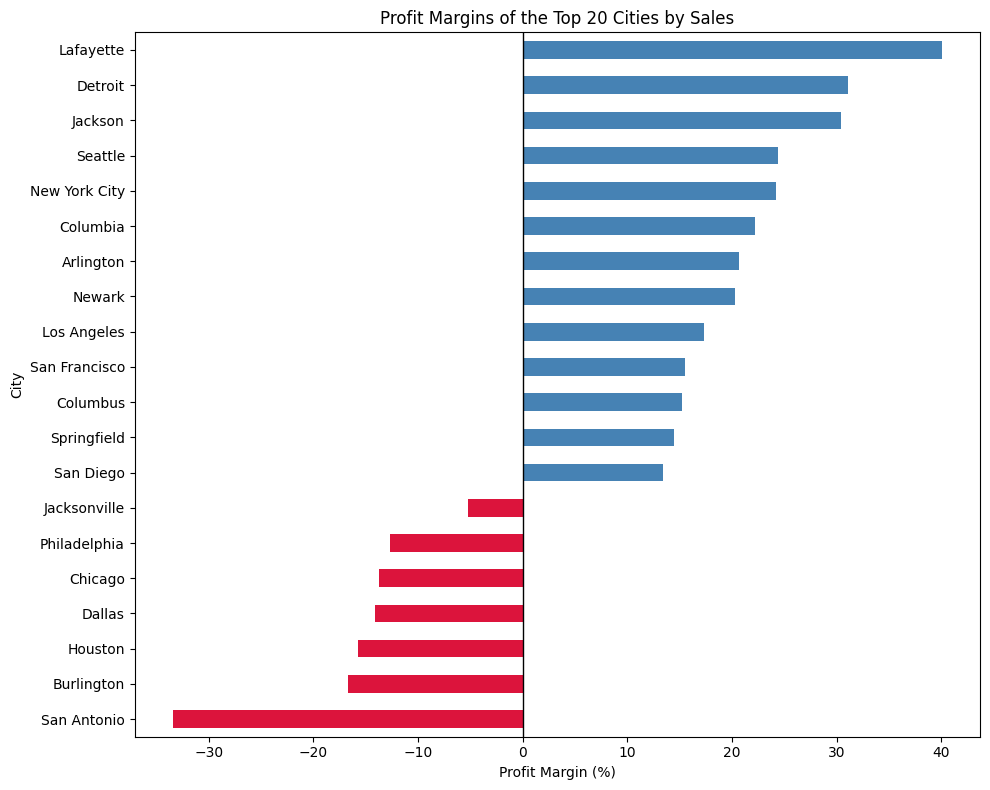

In [20]:
# Visualize profit margins among the Top-20 sales cities
margin_data = top_20_by_sales.sort_values('Profit_Margin_%')

colors = [
    'crimson' if margin < 0 else 'steelblue'
    for margin in margin_data['Profit_Margin_%']
]

ax = margin_data['Profit_Margin_%'].plot(
    kind='barh',
    figsize=(10, 8),
    color=colors
)

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Profit Margins of the Top 20 Cities by Sales')
ax.set_xlabel('Profit Margin (%)')
ax.set_ylabel('City')

plt.tight_layout()
plt.show()

Top 20 Customers by Sales:
Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Todd Sumrall          11891.751
Greg Tran             11820.120
Becky Martin          11789.630
Seth Vernon           11470.950
Caroline Jumper       11164.974
Clay Ludtke           10880.546
Maria Etezadi         10663.728
Karen Ferguson        10604.266
Bill Shonely          10501.653
Edward Hooks          10310.880
Name: Sales, dtype: float64


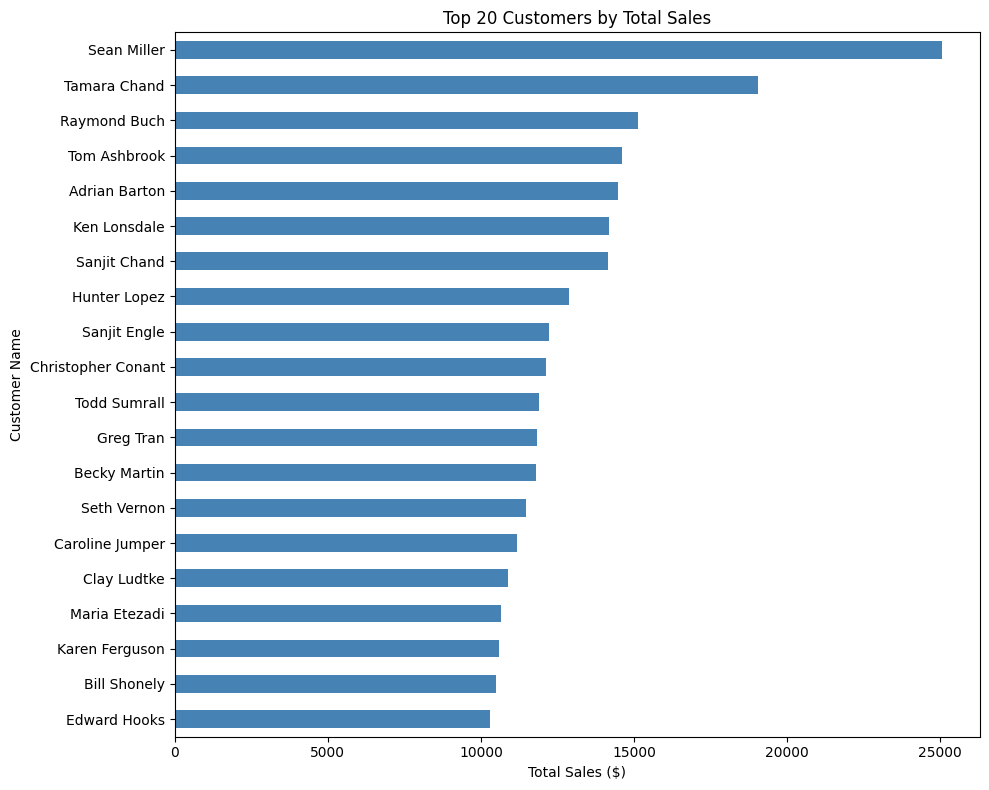

In [21]:
#What are the Top 20 customers by Sales?
top_20_customers_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)
print("Top 20 Customers by Sales:")
print(top_20_customers_sales)

# Visualize the Top-20 customer ranking
ax = top_20_customers_sales.sort_values().plot(
    kind='barh',
    figsize=(10, 8),
    color='steelblue'
)
ax.set_title('Top 20 Customers by Total Sales')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Customer Name')

plt.tight_layout()
plt.show()


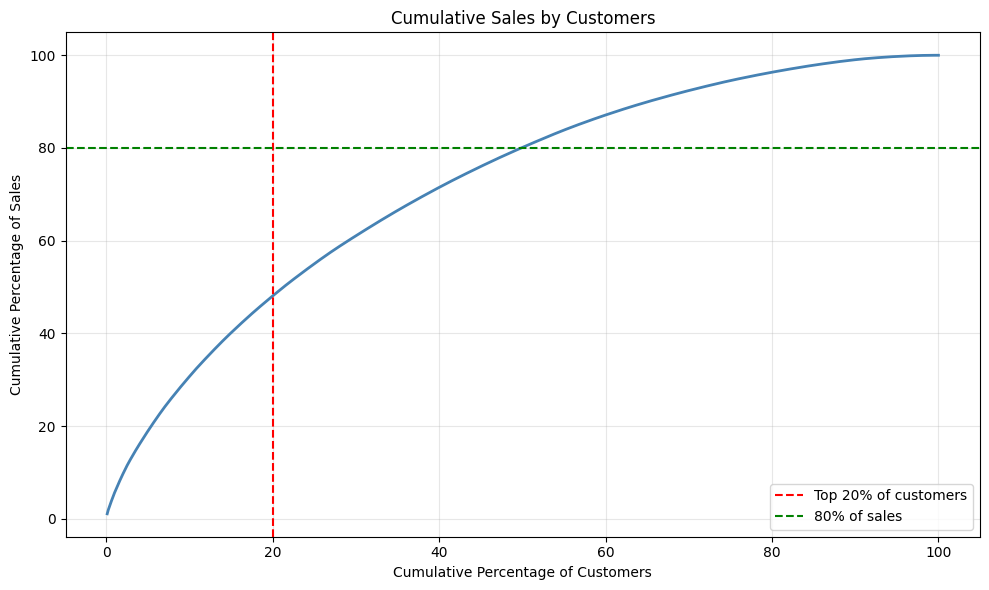

In [22]:
#Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?
#Calculate total sales per customer, highest to lowest
customer_sales = (
    df.groupby('Customer Name')['Sales']
    .sum()
    .sort_values(ascending=False)
)

# Calculate cumulative sales percentage
cumulative_sales = customer_sales.cumsum()
cumulative_sales_percentage = cumulative_sales / customer_sales.sum() * 100

# Calculate cumulative customer percentage
customer_percentage = (
    np.arange(1, len(customer_sales) + 1)
    / len(customer_sales)
    * 100
)

# Plot the cumulative sales curve
plt.figure(figsize=(10, 6))

plt.plot(
    customer_percentage,
    cumulative_sales_percentage,
    color='steelblue',
    linewidth=2
)

# Pareto reference lines
plt.axvline(20, color='red', linestyle='--', label='Top 20% of customers')
plt.axhline(80, color='green', linestyle='--', label='80% of sales')

plt.title('Cumulative Sales by Customers')
plt.xlabel('Cumulative Percentage of Customers')
plt.ylabel('Cumulative Percentage of Sales')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [23]:
# Number of customers representing the top 20%
top_20_percent_count = int(np.ceil(len(customer_sales) * 0.20))

# Percentage of sales generated by the top 20%
top_20_percent_sales = customer_sales.head(top_20_percent_count).sum()
top_20_percent_sales_share = (
    top_20_percent_sales / customer_sales.sum() * 100
)

print(f"Total customers: {len(customer_sales)}")
print(f"Customers in the top 20%: {top_20_percent_count}")
print(
    f"Sales generated by the top 20% of customers: "
    f"{top_20_percent_sales_share:.1f}%"
)

if top_20_percent_sales_share >= 80:
    print("The Pareto principle applies to customer sales.")
else:
    print("The Pareto principle does not strictly apply to customer sales.")

Total customers: 793
Customers in the top 20%: 159
Sales generated by the top 20% of customers: 48.1%
The Pareto principle does not strictly apply to customer sales.


In [24]:
customers_needed = np.argmax(cumulative_sales_percentage.values >= 80) + 1
customer_share_needed = customers_needed / len(customer_sales) * 100

print(
    f"{customers_needed} customers, or {customer_share_needed:.1f}% "
    "of customers, generate 80% of sales."
)

396 customers, or 49.9% of customers, generate 80% of sales.


## Marketing Strategy Recommendations

The primary marketing markets should be **California, New York, and Washington**. These states combine high sales volume with strong positive profit. California has the highest sales and profit, while New York and Washington produce stronger profit margins.

At the city level, marketing should prioritize **New York City, Los Angeles, Seattle, San Francisco, and Detroit**. These cities are among the strongest contributors to total profit and have demonstrated profitable customer demand.

Additional growth campaigns should be tested in **Michigan, Indiana, Georgia, and Virginia**. Although their sales are lower than California and New York, their strong profit margins suggest room for profitable expansion.

Marketing spending should be limited or carefully reviewed in **Texas, Pennsylvania, Ohio, and Illinois**. These states generate substantial sales but produce overall losses. Similarly, high-sales cities such as **Philadelphia, Houston, Chicago, Jacksonville, San Antonio, Burlington, and Dallas** should not receive broad sales-focused promotions until pricing, discounts, and product mix are investigated.

Customer targeting should differ by objective. The top 20% of customers generate approximately **81.7% of profit**, so profit-focused retention campaigns should target these customers. However, the top 20% generate only **48.1% of sales**, meaning broader customer coverage is required for sales-growth campaigns.
